# Week 1 — Single-Inertia Motor + PI Speed Control

We start with the simplest useful propulsion-control plant:

\[
J\dot{\omega}=T_m-T_L-b\omega
\]

where:

- \(J\): shaft inertia
- \(\omega\): shaft speed
- \(T_m\): commanded motor torque
- \(T_L\): external load torque
- \(b\omega\): viscous drag

The key idea is that **torque controls acceleration**, not speed directly.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [2]:
from dataclasses import dataclass

@dataclass
class SingleInertiaMotor:
    J: float = 0.05
    b: float = 0.02
    omega: float = 0.0

    def derivative(self, torque_cmd, torque_load=0.0):
        return (torque_cmd - torque_load - self.b*self.omega)/self.J

    def step(self, torque_cmd, torque_load, dt):
        self.omega += self.derivative(torque_cmd, torque_load)*dt
        return self.omega

@dataclass
class PIController:
    kp: float
    ki: float
    integral: float = 0.0

    def step(self, error, dt):
        self.integral += error*dt
        return self.kp*error + self.ki*self.integral

## Open-loop intuition

Apply constant torque with no controller. At first the motor accelerates quickly.
As speed rises, \(b\omega\) increases until motor torque is balanced by drag and load.

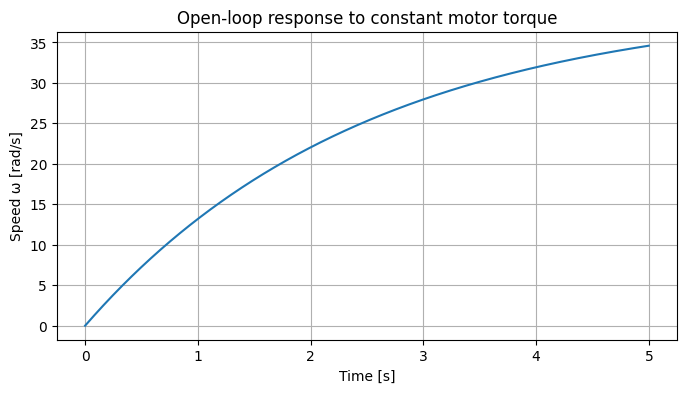

Final speed ≈ 34.59 rad/s
Expected equilibrium = (Tm-TL)/b = 40.00 rad/s


In [3]:
dt = 0.001
t = np.arange(0, 5, dt)
motor = SingleInertiaMotor()
omega = []

for _ in t:
    omega.append(motor.step(torque_cmd=1.0, torque_load=0.2, dt=dt))

plt.figure(figsize=(8,4))
plt.plot(t, omega)
plt.xlabel("Time [s]")
plt.ylabel("Speed ω [rad/s]")
plt.title("Open-loop response to constant motor torque")
plt.grid(True)
plt.show()

print(f"Final speed ≈ {omega[-1]:.2f} rad/s")
print(f"Expected equilibrium = (Tm-TL)/b = {(1.0-0.2)/0.02:.2f} rad/s")

## Close the loop with PI

The controller sees speed error

\[
e=\omega_{cmd}-\omega
\]

and commands

\[
T_m=K_p e+K_i\int e\,dt
\]

The proportional part reacts **now**. The integral part remembers accumulated error, which is why PI can remove steady-state error caused by a constant load.

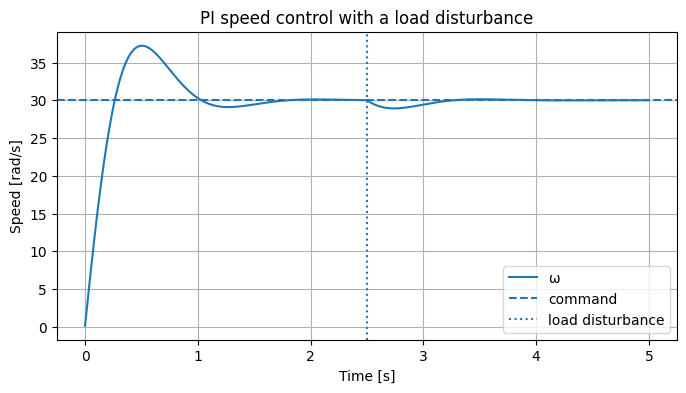

In [4]:
motor = SingleInertiaMotor()
ctrl = PIController(kp=0.25, ki=1.2)
omega_cmd = 30.0
omega = []
torque = []

for ti in t:
    load = 0.2 if ti < 2.5 else 0.7   # disturbance at 2.5 s
    e = omega_cmd - motor.omega
    u = ctrl.step(e, dt)
    omega.append(motor.step(u, load, dt))
    torque.append(u)

plt.figure(figsize=(8,4))
plt.plot(t, omega, label="ω")
plt.axhline(omega_cmd, linestyle="--", label="command")
plt.axvline(2.5, linestyle=":", label="load disturbance")
plt.xlabel("Time [s]")
plt.ylabel("Speed [rad/s]")
plt.title("PI speed control with a load disturbance")
plt.legend()
plt.grid(True)
plt.show()

## What to notice

1. The load disturbance initially slows the shaft.
2. That creates error.
3. The PI controller increases commanded torque.
4. The integral term keeps increasing until the constant load is cancelled.
5. Speed returns to the command.

**Try later:** set `ki=0`. You will recover the P-controller steady-state error we discussed.